# Demo for the ProblemsSolvers class.

This script is intended to help with debugging problems and solvers.

It create problem-solver groups (using the directory) and runs multiple macroreplications of each problem-solver pair.

## Append SimOpt Path

Since the notebook is stored in simopt/notebooks, we need to append the parent simopt directory to the system path to import the necessary modules later on.

In [1]:
import sys
from pathlib import Path

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

## Configuration Parameters

This section defines the core parameters for the demo.

To query model/problem/solver names, run `python scripts/list_directories.py`

In [2]:
# Specify the names of the solver(s) and problem(s) to test.
solver_abbr_names = [ "SQPASTRODF"]
problem_abbr_names = ["AMUSEMENTPARK-1"]
solver_factors = [{"easy_solve": False, "use_gradients":False}]
problem_factors = [{"budget":5000}]

num_macroreps = 1
num_postreps = 50
num_postreps_init_opt = 50

In [3]:
# Initialize an instance of the experiment class.
from simopt.experiment_base import ProblemsSolvers

mymetaexperiment = ProblemsSolvers(
    solver_names=solver_abbr_names, problem_names=problem_abbr_names, solver_factors = solver_factors, problem_factors = problem_factors
)

# Write to log file.
mymetaexperiment.log_group_experiment_results()

In [4]:
# Run a fixed number of macroreplications of each solver on each problem.
mymetaexperiment.run(n_macroreps=num_macroreps)

In [5]:
print("Post-processing results.")
# Run a fixed number of postreplications at all recommended solutions.
mymetaexperiment.post_replicate(n_postreps=num_postreps)

Post-processing results.


In [6]:
print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
mymetaexperiment.post_normalize(n_postreps_init_opt=num_postreps_init_opt)

Post-normalizing results.


In [9]:
mymetaexperiment.report_group_statistics()

Plotting results...
Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-05-21_17-51-46/plots/SOLVER_SET_AMUSEMENTPARK-1_all_prog_curves_unnorm.png')]
Plotting complete!


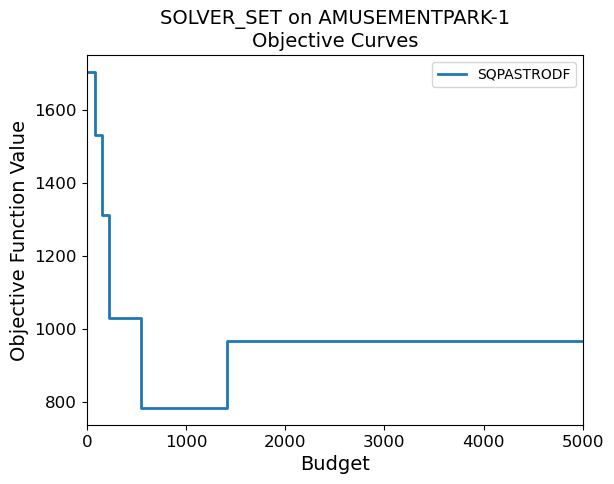

In [7]:
# Produce basic plots.

from simopt.experiment_base import (
    plot_area_scatterplots,  # noqa: F401
    plot_feasibility_progress,  # noqa: F401
    plot_progress_curves,  # noqa: F401
    plot_solvability_cdfs,  # noqa: F401
    plot_solvability_profiles,  # noqa: F401
    plot_terminal_feasibility,  # noqa: F401
    plot_terminal_progress,  # noqa: F401
    plot_terminal_scatterplots, 
    PlotType# noqa: F401
)

print("Plotting results...")


def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_progress_curves(
        experiments=mymetaexperiment.experiments[0], plot_type=PlotType.ALL, normalize=False
    )
)

print("Plotting complete!")